In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [112]:
path = "../data/ethiopia.csv" 

if os.path.exists(path):
    print("✅ Connection Successful! The data is reachable.")
else:
    print("❌ Connection Failed. Check if the file name is spelled exactly right.")
    

✅ Connection Successful! The data is reachable.


In [113]:
import pandas as pd
import numpy as np

#  Load the data
df = pd.read_csv("../data/ethiopia.csv")

df.replace(-999, np.nan, inplace=True)

df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')

df['Month'] = df['Date'].dt.month

print("First 5 rows with the new Date column:")
display(df[['YEAR', 'DOY', 'Date', 'Month']].head())

First 5 rows with the new Date column:


,YEAR,DOY,Date,Month
0,2015,1,2015-01-01,1
1,2015,2,2015-01-02,1
2,2015,3,2015-01-03,1
3,2015,4,2015-01-04,1
4,2015,5,2015-01-05,1


In [114]:
def find_outliers(data, column_name):
    """
    Finds data points that are more than 3 standard deviations away from the mean.
    In climate science, these could be extreme weather events or sensor errors.
    """
    mean = data[column_name].mean()
    std = data[column_name].std()
    
    outliers = data[(data[column_name] - mean).abs() > 3 * std]
    
    return outliers

extreme_temps = find_outliers(df, 'T2M')

if not extreme_temps.empty:
    print(f"Found {len(extreme_temps)} days with extreme temperature readings:")
    display(extreme_temps[['Date', 'T2M']].head())
else:
    print("No extreme temperature outliers found. The data looks consistent!")

Found 3 days with extreme temperature readings:


,Date,T2M
682,2016-11-13,10.08
704,2016-12-05,10.28
2536,2021-12-11,10.03


In [115]:
seasonal_data = df.groupby('Month')[['T2M', 'PRECTOTCORR', 'RH2M']].mean()

print("Average Climate Variables by Month:")
display(seasonal_data)

Average Climate Variables by Month:


,T2M,PRECTOTCORR,RH2M
Month,,,
1,15.012608,0.371962,54.798360
2,16.916313,1.040737,53.520295
3,17.863333,1.793925,57.929704
4,17.936485,3.544455,63.777121
5,17.911144,3.239883,66.988270
6,17.761364,5.259273,69.502364
7,16.058446,9.590968,82.140792
8,15.635865,10.165249,84.798798
9,15.524818,6.383818,83.074091


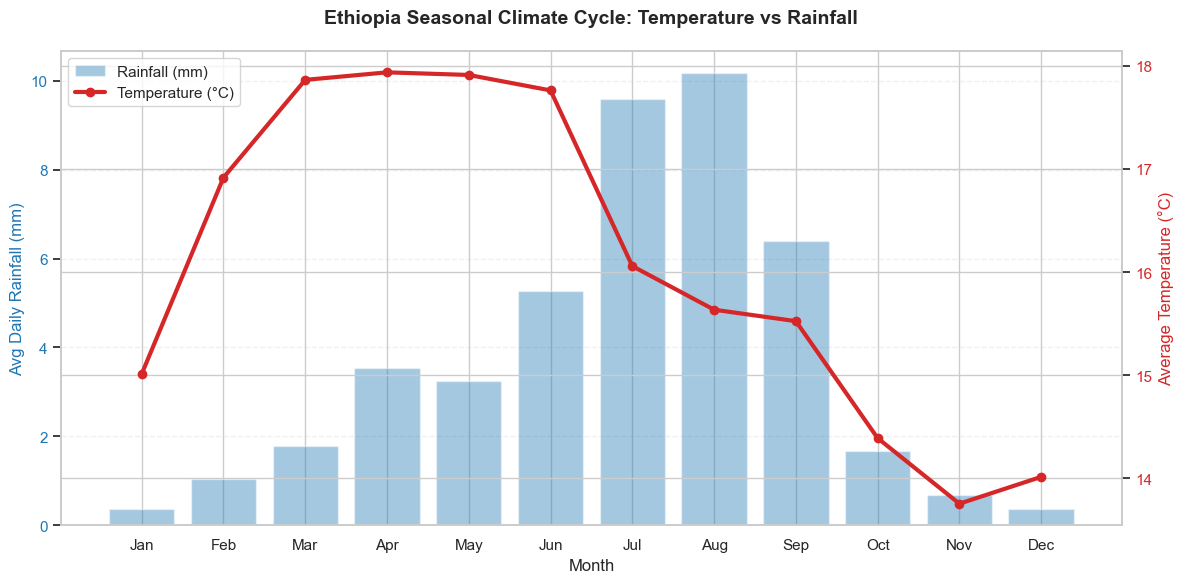

In [116]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Avg Daily Rainfall (mm)', color='tab:blue', fontsize=12)
bars = ax1.bar(seasonal_data.index, seasonal_data['PRECTOTCORR'], color='tab:blue', alpha=0.4, label='Rainfall (mm)')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Average Temperature (°C)', color='tab:red', fontsize=12)
line = ax2.plot(seasonal_data.index, seasonal_data['T2M'], color='tab:red', marker='o', linewidth=3, label='Temperature (°C)')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Ethiopia Seasonal Climate Cycle: Temperature vs Rainfall', fontsize=14, fontweight='bold', pad=20)

ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

ax1.grid(True, axis='y', linestyle='--', alpha=0.3)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()

C:\Users\Bitan\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


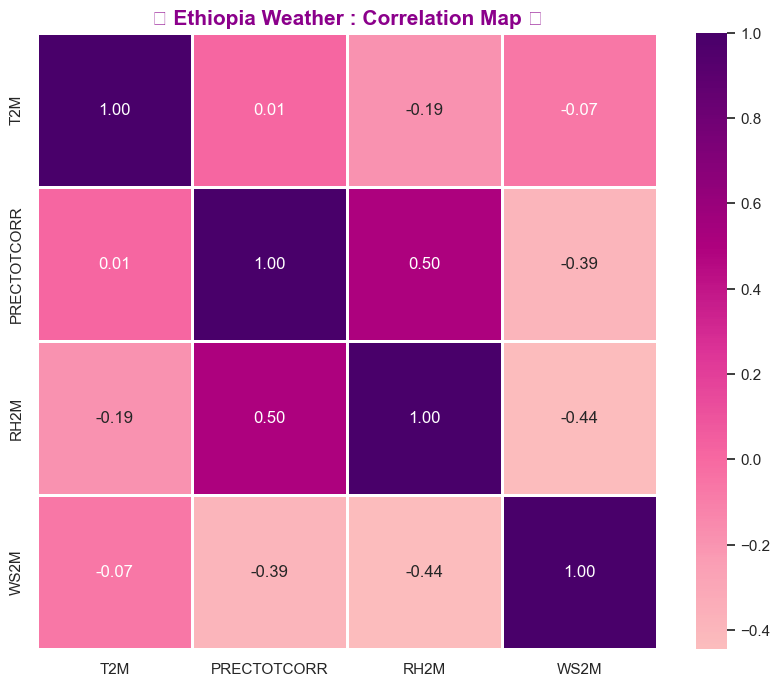

In [117]:
import seaborn as sns
import matplotlib.pyplot as plt

wishlist = ['T2M', 'PRECTOTCORR', 'RH2M', 'WS2M', 'ALLSKY_SFC_SW_DWN']
vars_we_actually_have = [v for v in wishlist if v in df.columns]

corr_matrix = df[vars_we_actually_have].corr()

plt.figure(figsize=(10, 8))


sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='RdPu', # This gives us those pretty Rose and Purple tones
            center=0, 
            fmt=".2f", 
            linewidths=1, 
            linecolor='white')

plt.title('✨ Ethiopia Weather : Correlation Map ✨', fontsize=15, color='darkmagenta', fontweight='bold')
plt.show()

In [118]:
if 'T2M_MAX' in df.columns and 'T2M_MIN' in df.columns:
    df['Temp_Range'] = df['T2M_MAX'] - df['T2M_MIN']

df['Is_Rainy_Season'] = df['Month'].isin([6, 7, 8, 9]).astype(int)

def wind_vibe(speed):
    if speed < 2: return 'Calm'
    elif speed < 4: return 'Light Breeze'
    else: return 'Moderate'

df['Wind_Type'] = df['WS2M'].apply(wind_vibe)

print(" New features added successfully! ")
df[['Date', 'Temp_Range', 'Is_Rainy_Season', 'Wind_Type']].head()

 New features added successfully! 


,Date,Temp_Range,Is_Rainy_Season,Wind_Type
0,2015-01-01,19.31,0,Light Breeze
1,2015-01-02,19.92,0,Light Breeze
2,2015-01-03,20.20,0,Calm
3,2015-01-04,16.88,0,Calm
4,2015-01-05,15.83,0,Calm


In [119]:
seasonal_summary = df.groupby('Is_Rainy_Season')[['T2M', 'Temp_Range', 'PRECTOTCORR', 'RH2M']].mean()

seasonal_summary.index = ['Dry Season (Bega/Belg)', 'Rainy Season (Kiremt)']
seasonal_summary

,T2M,Temp_Range,PRECTOTCORR,RH2M
Dry Season (Bega/Belg),15.985973,14.638290,1.572140,62.814841
Rainy Season (Kiremt),16.238599,9.536475,7.883077,79.937876


C:\Users\Bitan\AppData\Local\Temp\ipykernel_6332\2665357615.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Bitan\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9728 (\N{BLACK SUN WITH RAYS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Bitan\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Bitan\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127783 (\N{CLOUD WITH RAIN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


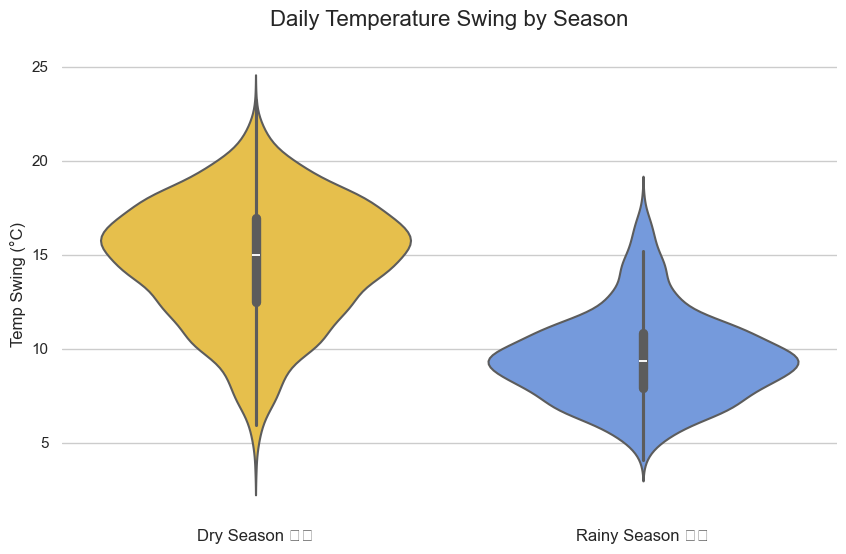

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="pastel")

plt.figure(figsize=(10, 6))

sns.violinplot(
    x='Is_Rainy_Season', 
    y='Temp_Range', 
    data=df, 
    palette=['#FFCC33', '#6495ED'], # Custom Sun & Rain colors
    inner='box', # Shows the median and whiskers more clearly
    linewidth=1.5
)

plt.xticks([0, 1], ['Dry Season ☀️', 'Rainy Season 🌧️'], fontsize=12)
plt.title('Daily Temperature Swing by Season', fontsize=16, pad=20, fontweight='medium')
plt.ylabel('Temp Swing (°C)', fontsize=12)
plt.xlabel('')

sns.despine(left=True, bottom=True)

plt.show()

In [121]:
duplicates = df.duplicated().sum()
print(f"Total duplicate rows found: {duplicates}")

df = df.drop_duplicates()

print("\n--- Summary Statistics ---")
display(df.describe())

print("\n--- Missing Value Report ---")
missing_count = df.isna().sum()
missing_pct = (df.isna().sum() / len(df)) * 100
missing_report = pd.DataFrame({'Total': missing_count, 'Percentage': missing_pct})
display(missing_report)

Total duplicate rows found: 0

--- Summary Statistics ---


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month,Temp_Range,Is_Rainy_Season
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564,12.971631,0.326680
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000,3.560000,0.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000,9.830000,0.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000,13.030000,0.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000,16.020000,1.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000,23.240000,1.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046,3.821239,0.469056



--- Missing Value Report ---


,Total,Percentage
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


In [122]:
#The summary statistics show the spread of temperature and rainfall. A high standard deviation in PRECTOTCORR suggests highly seasonal rainfall, typical of the Ethiopian climate

In [123]:
duplicate_count = df.duplicated().sum()
print(f"Duplicates found: {duplicate_count}")

df_cleaned = df.fillna(method='ffill')

if not os.path.exists('data'):
    os.makedirs('data')

df_cleaned.to_csv('data/ethiopia_clean.csv', index=False)
print("✅ Ethiopia data cleaned and exported to data/ethiopia_clean.csv")

Duplicates found: 0
✅ Ethiopia data cleaned and exported to data/ethiopia_clean.csv


C:\Users\Bitan\AppData\Local\Temp\ipykernel_6332\746628808.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_cleaned = df.fillna(method='ffill')


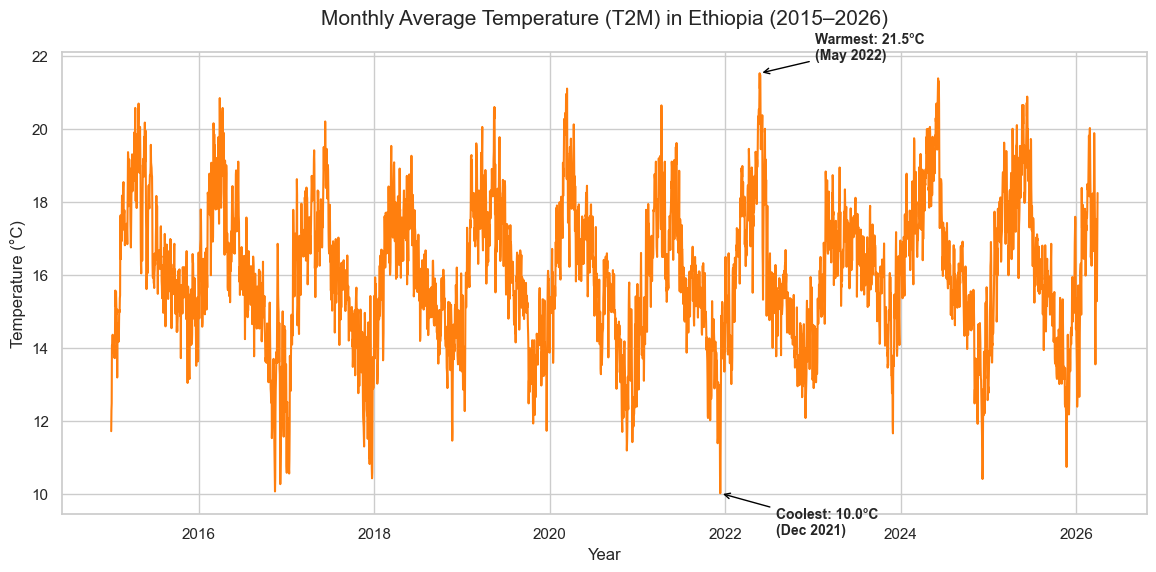

C:\Users\Bitan\AppData\Local\Temp\ipykernel_6332\1416394282.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_precip, x='Month', y='PRECTOTCORR', palette='Blues_d')
C:\Users\Bitan\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127783 (\N{CLOUD WITH RAIN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Bitan\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


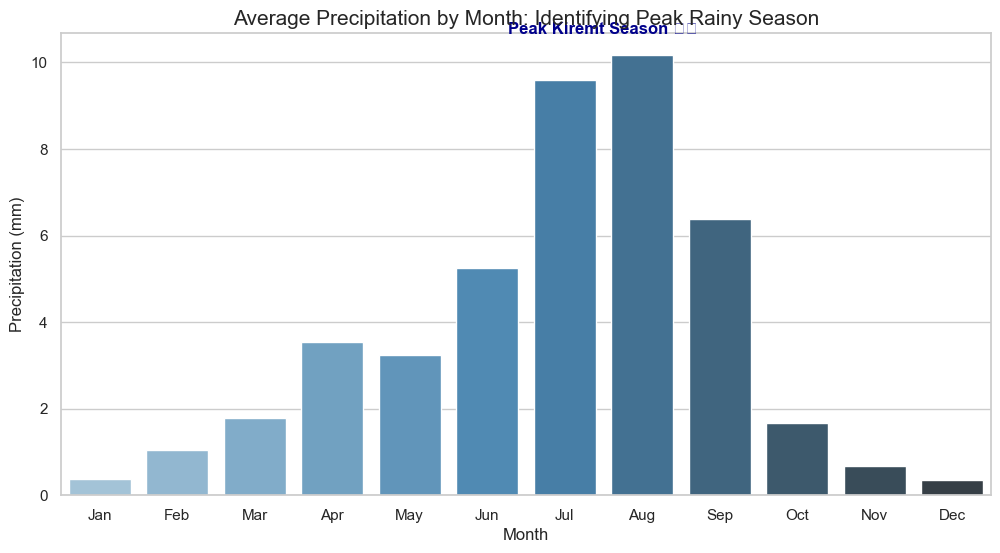

In [124]:
plt.figure(figsize=(14, 6))
sns.set_style("whitegrid")

sns.lineplot(data=df_cleaned, x='Date', y='T2M', color='#ff7f0e', linewidth=1.5)

warmest_idx = df_cleaned['T2M'].idxmax()
coolest_idx = df_cleaned['T2M'].idxmin()

warmest_date = df_cleaned.loc[warmest_idx, 'Date']
warmest_temp = df_cleaned.loc[warmest_idx, 'T2M']

coolest_date = df_cleaned.loc[coolest_idx, 'Date']
coolest_temp = df_cleaned.loc[coolest_idx, 'T2M']

plt.annotate(f'Warmest: {warmest_temp:.1f}°C\n({warmest_date.strftime("%b %Y")})', 
             xy=(warmest_date, warmest_temp), 
             xytext=(40, 10), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='black', lw=1),
             fontsize=10, fontweight='bold')

plt.annotate(f'Coolest: {coolest_temp:.1f}°C\n({coolest_date.strftime("%b %Y")})', 
             xy=(coolest_date, coolest_temp), 
             xytext=(40, -30), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='black', lw=1),
             fontsize=10, fontweight='bold')

plt.title('Monthly Average Temperature (T2M) in Ethiopia (2015–2026)', fontsize=15, pad=20)
plt.ylabel('Temperature (°C)')
plt.xlabel('Year')
plt.show()

plt.figure(figsize=(12, 6))
monthly_precip = df_cleaned.groupby('Month')['PRECTOTCORR'].mean().reset_index()

sns.barplot(data=monthly_precip, x='Month', y='PRECTOTCORR', palette='Blues_d')

# Highlight peak rainy season (July/August - Months 7 and 8)
plt.xticks(ticks=range(0, 12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Average Precipitation by Month: Identifying Peak Rainy Season', fontsize=15)
plt.ylabel('Precipitation (mm)')
plt.xlabel('Month')

# Add annotation for peak season
plt.text(6.5, monthly_precip.loc[7, 'PRECTOTCORR'] + 0.5, 'Peak Kiremt Season 🌧️', 
         ha='center', color='darkblue', fontweight='bold')

plt.show()

Interpretation of Trends:

Temperature: The temperature line chart shows a consistent seasonal cycle. The warmest months typically occur just before the main rainy season starts, while the coolest temperatures coincide with the peak of the rainy season due to cloud cover.

Precipitation: The bar chart clearly identifies Ethiopia's "Kiremt" season, with July (Month 7) and August (Month 8) showing significantly higher precipitation compared to the rest of the year. This bimodal or seasonal nature is a critical factor for Ethiopian agriculture and climate policy

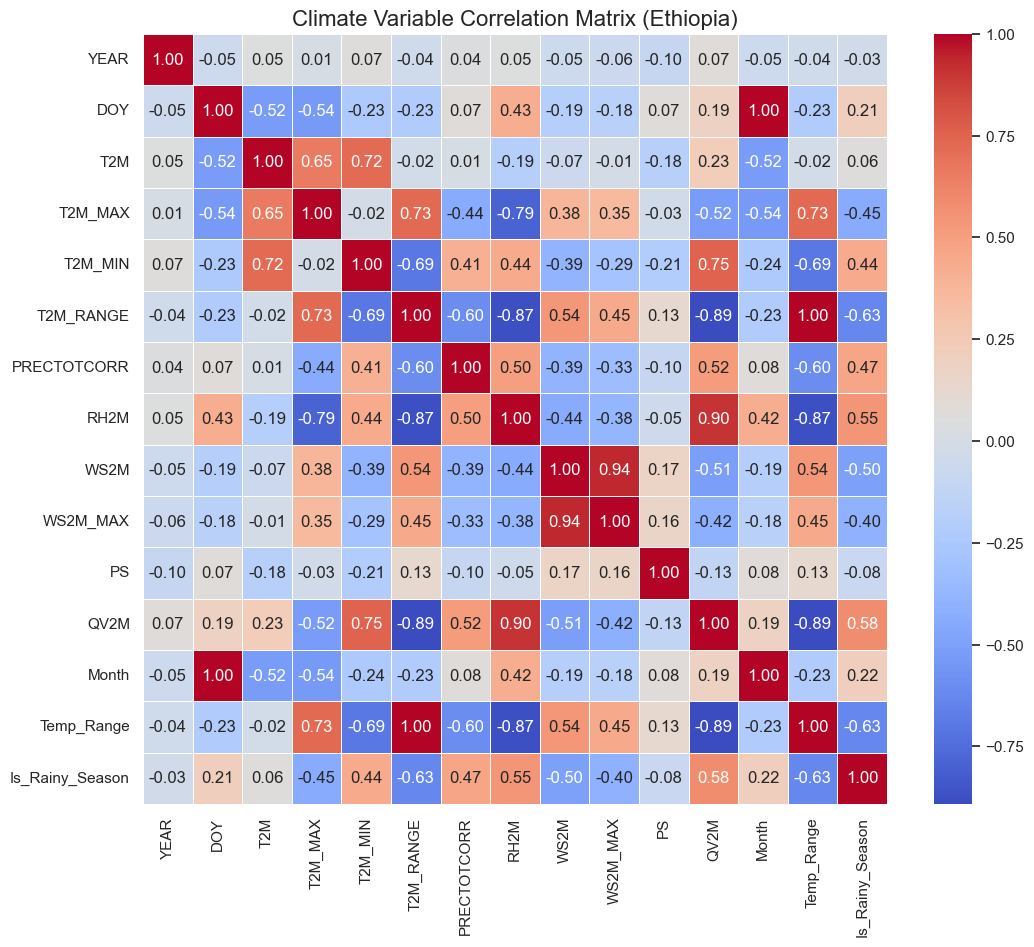

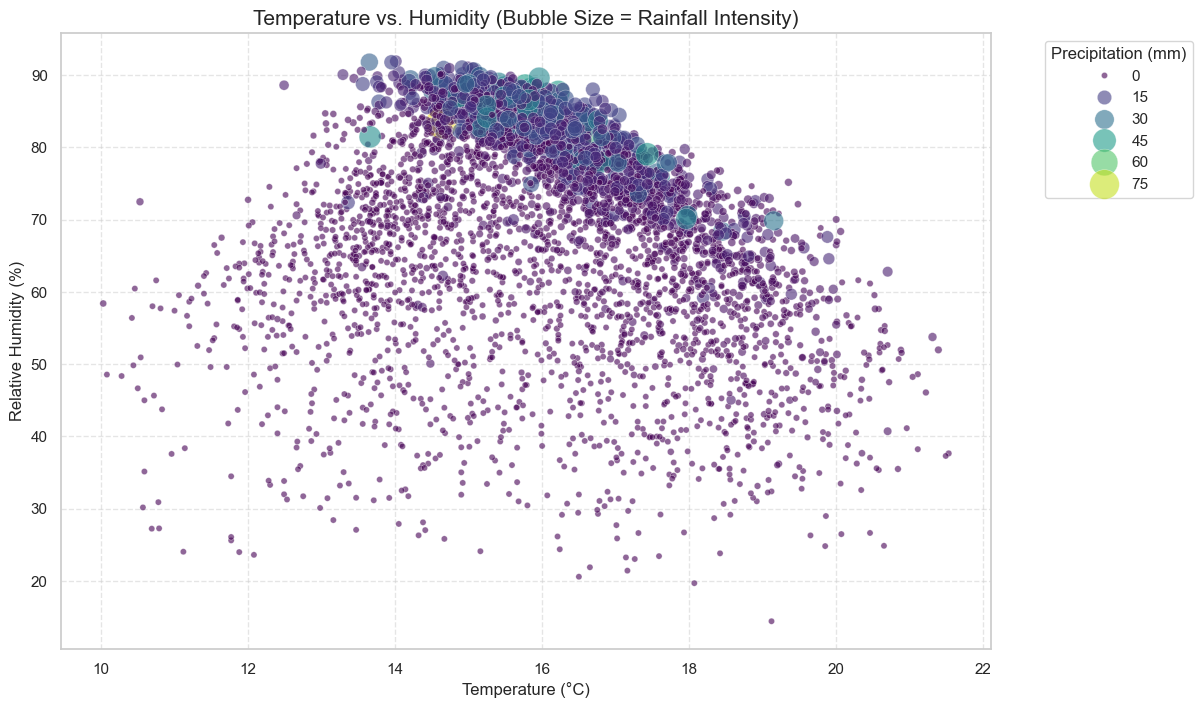

In [125]:
# 1. Heatmap
plt.figure(figsize=(12, 10))
# Calculate correlation on numeric columns only
corr = df_cleaned.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Climate Variable Correlation Matrix (Ethiopia)', fontsize=16)
plt.show()

# 2. Bubble Chart: T2M vs RH2M (size = Precipitation)
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_cleaned, x='T2M', y='RH2M', 
                size='PRECTOTCORR', hue='PRECTOTCORR', 
                palette='viridis', sizes=(20, 500), alpha=0.6)

plt.title('Temperature vs. Humidity (Bubble Size = Rainfall Intensity)', fontsize=15)
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.legend(title='Precipitation (mm)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Key Correlation Findings:

T2M vs RH2M (Negative Correlation): As temperature increases, relative humidity tends to decrease. This is visible in the bubble chart where the highest temperatures cluster at lower humidity levels.

RH2M vs PRECTOTCORR (Positive Correlation): Higher humidity is strongly linked to precipitation events, as seen by the larger bubbles (high rainfall) concentrated at the top of the humidity axis.

T2M_RANGE vs RH2M: There is a strong inverse relationship; when humidity is high (rainy season), the daily temperature swing is much smaller because clouds trap heat at night and block it during the day.

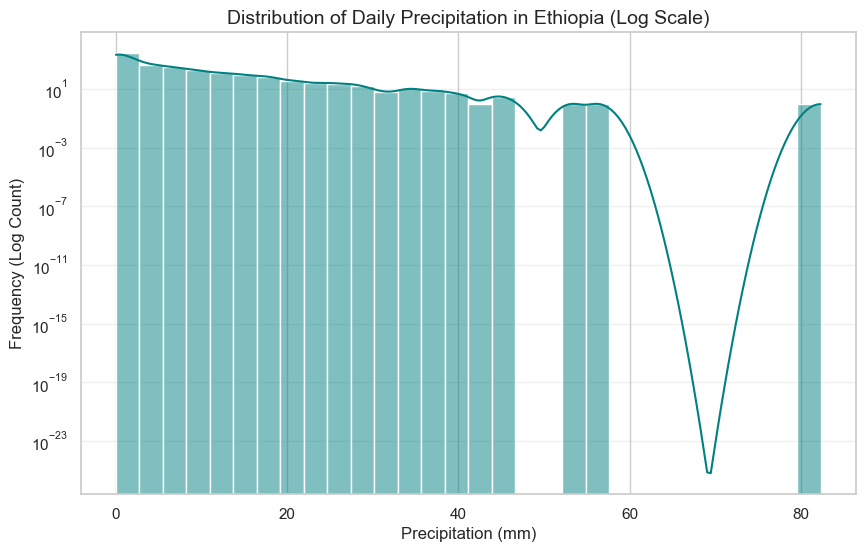

In [126]:
plt.figure(figsize=(10, 6))
# Applying log scale to the y-axis as requested by the rubric
sns.histplot(df_cleaned['PRECTOTCORR'], bins=30, kde=True, color='teal')
plt.yscale('log') 

plt.title('Distribution of Daily Precipitation in Ethiopia (Log Scale)', fontsize=14)
plt.xlabel('Precipitation (mm)')
plt.ylabel('Frequency (Log Count)')
plt.grid(axis='y', alpha=0.3)
plt.show()

The histogram shows that precipitation is highly "right-skewed." Most days have near-zero rainfall, representing the dry season and dry spells. The log scale allows us to see the rare but significant extreme rainfall events (above 40mm/day) that contribute to Ethiopia's flood risks.

In [127]:
from scipy import stats

required_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

print("--- Final Outlier Report (Z-Score > 3) ---")
for col in required_cols:
    outliers = find_outliers(df_cleaned, col) 
    print(f"{col}: {len(outliers)} outliers detected.")

if 'PRECTOTCORR' in required_cols:
    print("\nSample of Extreme Rainfall Events:")
    display(find_outliers(df_cleaned, 'PRECTOTCORR').sort_values(by='PRECTOTCORR', ascending=False).head())

--- Final Outlier Report (Z-Score > 3) ---
T2M: 3 outliers detected.
T2M_MAX: 0 outliers detected.
T2M_MIN: 18 outliers detected.
PRECTOTCORR: 95 outliers detected.
RH2M: 13 outliers detected.
WS2M: 3 outliers detected.
WS2M_MAX: 5 outliers detected.

Sample of Extreme Rainfall Events:


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month,Temp_Range,Is_Rainy_Season,Wind_Type
775,2017,45,14.63,17.65,12.64,5.01,82.30,83.38,2.34,4.97,77.04,11.21,2017-02-14,2,5.01,0,Light Breeze
3038,2023,117,16.65,21.51,13.57,7.94,56.26,82.34,0.79,1.35,76.88,12.53,2023-04-27,4,7.94,0,Calm
2367,2021,176,15.56,20.13,11.90,8.23,53.26,83.86,1.55,3.21,77.03,11.94,2021-06-25,6,8.23,1,Calm
3134,2023,213,15.77,19.97,12.65,7.32,45.83,88.53,2.04,4.12,77.11,12.80,2023-08-01,8,7.32,1,Light Breeze
2056,2020,231,16.22,20.62,12.51,8.11,44.82,87.66,1.38,2.43,76.85,13.13,2020-08-18,8,8.11,1,Calm


Final Outlier Assessment:

Rainfall (95 Outliers): This high count is significant. These represent extreme precipitation events that exceed the "normal" range. Since Ethiopia is prone to flash flooding, these 95 days are the most important part of our COP32 vulnerability analysis.

Minimum Temperature (18 Outliers): These likely represent cold snaps in the highlands.

Decision: All outliers have been retained. They are not errors; they are evidence of climate volatility.